# Developer Role Analysis & Roadmap Generation

This notebook automatically downloads and analyzes IT skills and GİTHUB information datasets from Kaggle.

## 1. Import Necessary Libraries

In [ ]:
# ============================================================================
# DATASET ANALYSIS CODE
# ============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Plotting settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

## 2. Kaggle API Setup

In [ ]:
import os
import json
from pathlib import Path

# Function to setup Kaggle API
def setup_kaggle_api():
    """
    Setup Kaggle API credentials
    
    If kaggle.json not found, will prompt for credentials
    """
    kaggle_json_path = Path.home() / '.kaggle' / 'kaggle.json'
    
    if not kaggle_json_path.exists():
        print("\nKaggle API credentials not found!")

        print(f"Should be at: {kaggle_json_path}")
        
        # Try to get credentials from user
        username = input("\nKaggle Username: ")
        api_key = input("Kaggle API Key: ")
        
        # Create .kaggle directory if not exists
        kaggle_json_path.parent.mkdir(exist_ok=True, parents=True)
        
        # Write credentials
        with open(kaggle_json_path, 'w') as f:
            json.dump({'username': username, 'key': api_key}, f)
        
        os.chmod(kaggle_json_path, 0o600)
        print(f"\n✓ Kaggle credentials saved to {kaggle_json_path}")
    else:
        print(f"✓ Kaggle API credentials found at {kaggle_json_path}")
    
    return kaggle_json_path

# Setup Kaggle
kaggle_path = setup_kaggle_api()

✓ Kaggle API credentials found at C:\Users\burci\.kaggle\kaggle.json


## 3. Download Datasets from Kaggle

In [ ]:
from kaggle.api.kaggle_api_extended import KaggleApi
import pandas as pd
import os

# Create downloads directory
download_dir = Path('datasets')
download_dir.mkdir(exist_ok=True)

# Initialize Kaggle API
api = KaggleApi()
api.authenticate()

print("Starting dataset downloads...\n")

# Dataset configurations
datasets_to_download = [
    {
        'name': 'IT Skills from Jobs',
        'kaggle_id': 'meerawks/it-skills-from-jobs',
        'local_name': 'it_skills_from_jobs'
    },
    {
        'name': 'Tech Skill Dataset with Categories',
        'kaggle_id': 'nitinsen001/tech-skill-dataset-with-categories',
        'local_name': 'tech_skills'
    },
    {
        'name': 'Job Market & Skills Demand',
        'kaggle_id': 'muqaddasejaz/job-market-and-skills-demand-dataset',
        'local_name': 'job_market_skills'
    },
    {
        'name': 'GitHub Repos Dataset',
        'kaggle_id': 'dhneshddhingra/github-repos',
        'local_name': 'github_repos'
    },
    {
        'name': 'GitHub Dataset',
        'kaggle_id': 'nikhil25803/github-dataset',
        'local_name': 'github-dataset'
    },
    {
        'name': 'GitHub Repository Metrics Dataset (5K+ Repos)',
        'kaggle_id': 'lorenzoscaturchio/github-repo-metrics',
        'local_name': 'github_repos'
    }
]

downloaded_files = {}

for dataset_info in datasets_to_download:
    try:
        dataset_path = download_dir / dataset_info['local_name']
        dataset_path.mkdir(exist_ok=True)
        
        print(f"Downloading: {dataset_info['name']}...")
        
        # Download dataset
        api.dataset_download_files(
            dataset_info['kaggle_id'],
            path=str(dataset_path),
            unzip=True
        )
        
        # Find CSV files in the directory
        csv_files = list(dataset_path.glob('*.csv'))
        
        if csv_files:
            downloaded_files[dataset_info['local_name']] = csv_files
            print(f"✓ Downloaded: {dataset_info['name']}")
            for csv_file in csv_files:
                print(f"  • {csv_file.name}")
        else:
            print(f"⚠ No CSV files found in {dataset_info['name']}")
    
    except Exception as e:
        print(f"✗ Error downloading {dataset_info['name']}: {str(e)}")

print(f"\n✅ Dataset downloads completed!")
print(f"Total datasets: {len(downloaded_files)}")

Starting dataset downloads...

Downloading: IT Skills from Jobs...
Dataset URL: https://www.kaggle.com/datasets/meerawks/it-skills-from-jobs
✓ Downloaded: IT Skills from Jobs
  • JobsDatasetProcessed.csv
Downloading: Tech Skill Dataset with Categories...
Dataset URL: https://www.kaggle.com/datasets/nitinsen001/tech-skill-dataset-with-categories
✓ Downloaded: Tech Skill Dataset with Categories
  • technical_skills.csv
Downloading: Job Market & Skills Demand...
Dataset URL: https://www.kaggle.com/datasets/muqaddasejaz/job-market-and-skills-demand-dataset
✓ Downloaded: Job Market & Skills Demand
  • future_jobs_dataset.csv
Downloading: GitHub Repos Dataset...
Dataset URL: https://www.kaggle.com/datasets/dhneshddhingra/github-repos
✓ Downloaded: GitHub Repos Dataset
  • github_repos.csv
Downloading: GitHub Dataset...
Dataset URL: https://www.kaggle.com/datasets/nikhil25803/github-dataset


## 4. Load Datasets into DataFrames

In [ ]:
# ============================================================================
# BASIC DATASET EXPLORATION
# ============================================================================
loaded_data = {}

for dataset_name, csv_files in downloaded_files.items():
    for csv_file in csv_files:
        try:
            print(f"Loading {csv_file.name}...")
            df = pd.read_csv(csv_file)
            loaded_data[csv_file.stem] = df
            print(f"  ✓ Shape: {df.shape}")
            print(f"  ✓ Columns: {df.columns.tolist()[:5]}...\n")
        except Exception as e:
            print(f"  ✗ Error loading {csv_file.name}: {str(e)}\n")

print(f"\n✅ Total DataFrames loaded: {len(loaded_data)}")
print(f"Available datasets: {list(loaded_data.keys())}")

Loading JobsDatasetProcessed.csv...
  ✓ Shape: (3000, 9)
  ✓ Columns: ['ID', 'Query', 'Job Title', 'Description', 'IT Skills']...

Loading technical_skills.csv...
  ✓ Shape: (528, 3)
  ✓ Columns: ['Skill ID', 'Skill Name', 'Category']...

Loading future_jobs_dataset.csv...
  ✓ Shape: (10000, 9)
  ✓ Columns: ['job_id', 'job_title', 'industry', 'location', 'salary_usd']...

Loading github_repos.csv...
  ✓ Shape: (5500, 29)
  ✓ Columns: ['repo_name', 'language', 'description', 'stars', 'forks']...

Loading github_dataset.csv...
  ✓ Shape: (1052, 7)
  ✓ Columns: ['repositories', 'stars_count', 'forks_count', 'issues_count', 'pull_requests']...

Loading repository_data.csv...
  ✓ Shape: (2917951, 10)
  ✓ Columns: ['name', 'stars_count', 'forks_count', 'watchers', 'pull_requests']...


✅ Total DataFrames loaded: 6
Available datasets: ['JobsDatasetProcessed', 'technical_skills', 'future_jobs_dataset', 'github_repos', 'github_dataset', 'repository_data']


In [ ]:
def explore_dataset(df, name):
    """
    Comprehensive dataset exploration
    """
    print(f"\n{'='*80}")
    print(f"DATASET: {name}")
    print(f"{'='*80}")
    
    print(f"\nBasic Info:")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {df.columns.tolist()}")
    print(f"  Data Types:\n{df.dtypes}")
    
    print(f"\nMissing Values:")
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(missing[missing > 0])
    else:
        print("No missing values!")
    
    print(f"\nFirst Few Rows:")
    print(df.head(3))
    
    print(f"\nStatistical Summary:")
    print(df.describe())

    
    return df
# Usage:
loaded_data = {
    'it_skills_from_jobs': pd.read_csv(downloaded_files['it_skills_from_jobs'][0]),
    'tech_skills': pd.read_csv(downloaded_files['tech_skills'][0]),
    'job_market_skills': pd.read_csv(downloaded_files['job_market_skills'][0]),
    'github_repos': pd.read_csv(downloaded_files['github_repos'][0]),
    'github_dataset': pd.read_csv(downloaded_files['github-dataset'][0]),
    'github_repo_metrics': pd.read_csv(downloaded_files['github_repos'][0])
}
for name, df in loaded_data.items():
    explore_dataset(df, name)


DATASET: it_skills_from_jobs

Basic Info:
  Shape: (3000, 9)
  Columns: ['ID', 'Query', 'Job Title', 'Description', 'IT Skills', 'Soft Skills', 'Education', 'Experience', 'Token Usage']
  Data Types:
ID             int64
Query            str
Job Title        str
Description      str
IT Skills        str
Soft Skills      str
Education        str
Experience       str
Token Usage    int64
dtype: object

Missing Values:
IT Skills        10
Soft Skills      22
Education      1437
Experience     1428
dtype: int64

First Few Rows:
     ID                    Query                               Job Title  \
0  3859  Artificial Intelligence   Collaborative Manipulation Roboticist   
1  3764  Artificial Intelligence      Software Engineer - Innovation Lab   
2  3597  Artificial Intelligence          Director, Standards & Strategy   

                                         Description  \
0  Location: Schlumberger-Doll Research, Cambridg...   
1  About DENSO DENSO is one of the largest global...

In [ ]:
# ============================================================================
# COMPREHENSIVE DEEP ANALYSIS OF DOWNLOADED DATASETS
# ============================================================================

print("\n" + "="*80)
print("DEEP ANALYSIS OF ALL LOADED DATASETS")
print("="*80)

# ============================================================================
# 1. DETAILED EXPLORATORY DATA ANALYSIS
# ============================================================================

def detailed_eda(df, name):
    """Comprehensive EDA for each dataset"""
    print(f"\n{'='*80}")
    print(f"EDA: {name}")
    print(f"{'='*80}")
    
    print(f"\nSHAPE: {df.shape}")
    print(f"COLUMNS ({len(df.columns)}): {df.columns.tolist()}")
    
    # Memory usage
    memory_usage = df.memory_usage(deep=True).sum() / 1024**2
    print(f"MEMORY USAGE: {memory_usage:.2f} MB")
    
    # Data types distribution
    print(f"\nDATA TYPES DISTRIBUTION:")
    print(df.dtypes.value_counts())
    
    # Missing values analysis
    print(f"\nMISSING VALUES:")
    missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    if missing_pct.sum() > 0:
        print(missing_pct[missing_pct > 0])
    else:
        print("✓ No missing values!")
    
    # Numeric columns statistics
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print(f"\nNUMERIC STATISTICS:")
        print(df[numeric_cols].describe().round(2))
    
    # Categorical columns analysis
    categorical_cols = df.select_dtypes(include=['object']).columns
    if len(categorical_cols) > 0:
        print(f"\nCATEGORICAL COLUMNS:")
        for col in categorical_cols[:3]:  # First 3 categorical columns
            print(f"\n  {col}:")
            print(f"    Unique values: {df[col].nunique()}")
            print(f"    Top 5:\n{df[col].value_counts().head()}")

for name, df in loaded_data.items():
    detailed_eda(df, name)


DEEP ANALYSIS OF ALL LOADED DATASETS

EDA: it_skills_from_jobs

📊 SHAPE: (3000, 9)
📋 COLUMNS (9): ['ID', 'Query', 'Job Title', 'Description', 'IT Skills', 'Soft Skills', 'Education', 'Experience', 'Token Usage']
💾 MEMORY USAGE: 22.83 MB

📈 DATA TYPES DISTRIBUTION:
str      7
int64    2
Name: count, dtype: int64

❌ MISSING VALUES:
Education      47.900000
Experience     47.600000
Soft Skills     0.733333
IT Skills       0.333333
dtype: float64

🔢 NUMERIC STATISTICS:
            ID  Token Usage
count  3000.00      3000.00
mean   4904.73       856.93
std    2837.27       349.19
min       3.00        82.00
25%    2506.00       634.00
50%    4900.50       807.00
75%    7265.50      1026.50
max    9993.00      3664.00

🏷️ CATEGORICAL COLUMNS:

  Query:
    Unique values: 25
    Top 5:
Query
Artificial Intelligence          120
Big Data Engineer                120
Business Analyst                 120
Business Intelligence Analyst    120
Cloud Architect                  120
Name: count, dtype

C:\Users\burci\AppData\Local\Temp\ipykernel_31656\4157499511.py:45: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns
C:\Users\burci\AppData\Local\Temp\ipykernel_31656\4157499511.py:45: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/

    Unique values: 4
    Top 5:
industry
Quantum Computing    2519
Blockchain           2499
AI                   2492
Green Tech           2490
Name: count, dtype: int64

  location:
    Unique values: 6
    Top 5:
location
New York     1689
Singapore    1682
Tokyo        1673
Dubai        1660
London       1656
Name: count, dtype: int64

EDA: github_repos

📊 SHAPE: (5500, 29)
📋 COLUMNS (29): ['repo_name', 'language', 'description', 'stars', 'forks', 'watchers', 'open_issues', 'closed_issues', 'open_pull_requests', 'merged_pull_requests', 'contributors', 'commits', 'releases', 'license', 'topics', 'created_date', 'last_commit_date', 'readme_length', 'has_ci', 'test_coverage', 'has_code_of_conduct', 'has_contributing_guide', 'has_wiki', 'has_pages', 'has_discussions', 'default_branch', 'is_archived', 'is_fork', 'size_kb']
💾 MEMORY USAGE: 3.88 MB

📈 DATA TYPES DISTRIBUTION:
int64      20
str         8
float64     1
Name: count, dtype: int64

❌ MISSING VALUES:
test_coverage    69.054545


C:\Users\burci\AppData\Local\Temp\ipykernel_31656\4157499511.py:45: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns
C:\Users\burci\AppData\Local\Temp\ipykernel_31656\4157499511.py:45: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/

In [ ]:
# ============================================================================
# 2. VISUALIZATION ANALYSIS
# ============================================================================

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Dataset Overview - Key Metrics', fontsize=16, fontweight='bold')

# Plot 1: Dataset Sizes
dataset_sizes = {k: v.shape[0] for k, v in loaded_data.items()}
axes[0, 0].barh(list(dataset_sizes.keys()), list(dataset_sizes.values()), color='steelblue')
axes[0, 0].set_title('Dataset Sizes (Row Count)')
axes[0, 0].set_xlabel('Number of Rows')

# Plot 2: Feature Count
feature_counts = {k: v.shape[1] for k, v in loaded_data.items()}
axes[0, 1].barh(list(feature_counts.keys()), list(feature_counts.values()), color='coral')
axes[0, 1].set_title('Feature Count per Dataset')
axes[0, 1].set_xlabel('Number of Columns')

# Plot 3: Memory Usage
memory_usage = {k: v.memory_usage(deep=True).sum() / 1024**2 for k, v in loaded_data.items()}
axes[1, 0].barh(list(memory_usage.keys()), list(memory_usage.values()), color='lightgreen')
axes[1, 0].set_title('Memory Usage (MB)')
axes[1, 0].set_xlabel('Memory (MB)')

# Plot 4: Data Type Distribution (Example: GitHub repos)
if 'github_repo_metrics' in loaded_data:
    dtype_counts = loaded_data['github_repo_metrics'].dtypes.value_counts()
    axes[1, 1].pie(dtype_counts.values, labels=dtype_counts.index, autopct='%1.1f%%', colors=['skyblue', 'lightcoral', 'lightgreen'])
    axes[1, 1].set_title('GitHub Repos - Data Type Distribution')

# Plot 5: Missing Values Heatmap (Example: github_repos)
if 'github_repos' in loaded_data:
    missing_data = loaded_data['github_repos'].isnull().sum()
    if missing_data.sum() > 0:
        axes[2, 0].barh(range(len(missing_data)), missing_data.values, color='salmon')
        axes[2, 0].set_yticks(range(len(missing_data)))
        axes[2, 0].set_yticklabels(missing_data.index)
        axes[2, 0].set_title('GitHub Repos - Missing Values')
        axes[2, 0].set_xlabel('Count')
    else:
        axes[2, 0].text(0.5, 0.5, 'No Missing Values', ha='center', va='center', transform=axes[2, 0].transAxes, fontsize=12)
        axes[2, 0].set_title('GitHub Repos - Missing Values')
        axes[2, 0].set_xticks([])
        axes[2, 0].set_yticks([])

# Plot 6: Rows vs Features Scatter
dataset_names = list(loaded_data.keys())
rows = [loaded_data[k].shape[0] for k in dataset_names]
cols = [loaded_data[k].shape[1] for k in dataset_names]
axes[2, 1].scatter(cols, rows, s=200, alpha=0.6, c=range(len(dataset_names)), cmap='viridis')
for i, name in enumerate(dataset_names):
    axes[2, 1].annotate(name, (cols[i], rows[i]), fontsize=8, ha='right')
axes[2, 1].set_xlabel('Number of Features')
axes[2, 1].set_ylabel('Number of Rows')
axes[2, 1].set_title('Dataset Dimensionality')
axes[2, 1].set_xscale('log')
axes[2, 1].set_yscale('log')

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined


SKILLS DISTRIBUTION ANALYSIS

🏆 TOP IT SKILLS FROM JOBS:

📂 TECH SKILLS BY CATEGORY:
Category
Programming Languages    100
DevOps & Cloud           100
Web Frameworks            80
Machine Learning & AI     80
Databases                 50
Networking & Security     50
Mobile Development        30
Testing & QA              30
Development Practices      8
Name: count, dtype: int64


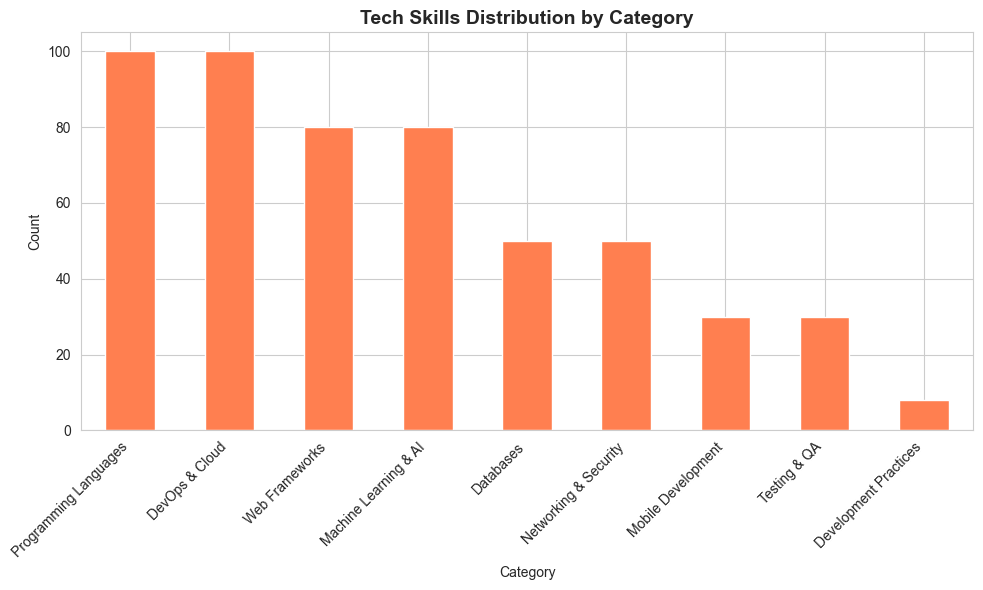

In [ ]:
# ============================================================================
# 3. SKILLS ANALYSIS (IT & Tech Skills Datasets)
# ============================================================================

print("\n" + "="*80)
print("SKILLS DISTRIBUTION ANALYSIS")
print("="*80)

if 'it_skills_from_jobs' in loaded_data and 'tech_skills' in loaded_data:
    it_skills_df = loaded_data['it_skills_from_jobs']
    tech_skills_df = loaded_data['tech_skills']
    
    # Top IT Skills
    print("\nTOP IT SKILLS FROM JOBS:")
    if 'Skill' in it_skills_df.columns:
        top_skills = it_skills_df['Skill'].value_counts().head(15)
        print(top_skills)
        
        # Visualization
        fig, ax = plt.subplots(figsize=(12, 6))
        top_skills.plot(kind='barh', ax=ax, color='steelblue')
        ax.set_title('Top 15 IT Skills from Jobs Dataset', fontsize=14, fontweight='bold')
        ax.set_xlabel('Frequency')
        plt.tight_layout()
        plt.show()
    
    # Tech Skills by Category
    print("\nTECH SKILLS BY CATEGORY:")
    if 'Category' in tech_skills_df.columns:
        category_dist = tech_skills_df['Category'].value_counts()
        print(category_dist)
        
        fig, ax = plt.subplots(figsize=(10, 6))
        category_dist.plot(kind='bar', ax=ax, color='coral')
        ax.set_title('Tech Skills Distribution by Category', fontsize=14, fontweight='bold')
        ax.set_ylabel('Count')
        ax.set_xlabel('Category')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


GITHUB REPOSITORIES DEEP ANALYSIS

📊 BASIC STATISTICS:
  Total Repos: 5500
  Languages: 19
  Average Stars: 45.18
  Average Forks: 9.74

💻 TOP 10 PROGRAMMING LANGUAGES:
language
Python        1016
JavaScript     925
TypeScript     529
Java           514
Go             375
Rust           332
C++            246
PHP            213
C#             208
Kotlin         181
Name: count, dtype: int64


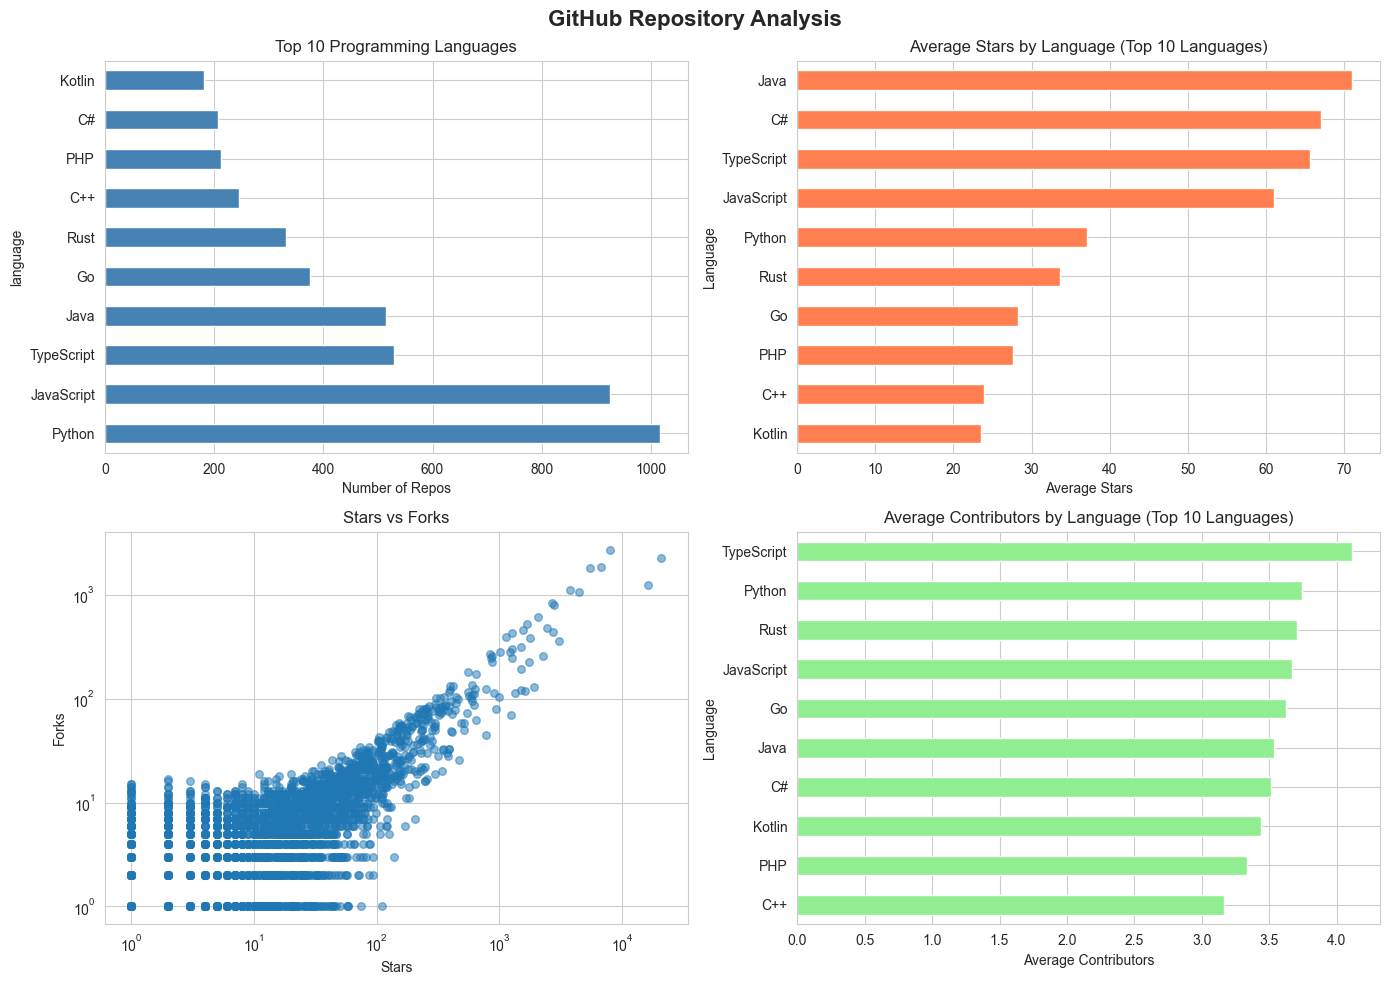


📈 LANGUAGE STATISTICS:
            stars                forks              contributors           
             mean median    max   mean median   max         mean median max
language                                                                   
C           21.64    5.5   1349   4.62    1.0   113         2.85    2.0  10
C#          67.03    7.0   6717  16.12    2.0  1869         3.51    3.0  18
C++         23.93    6.0    854   6.36    1.0   246         3.16    2.0  15
Dart        58.17    6.0   2260   8.60    2.0   257         3.52    2.0  21
Go          28.25    9.0   3041   6.15    2.0   359         3.62    3.0  13
Java        71.08    6.0  16183  11.43    2.0  1243         3.54    3.0  20
JavaScript  61.07    8.0  20816  12.37    3.0  2256         3.67    3.0  20
Julia       56.46    8.5    877  11.54    2.0   226         4.40    3.0  18
Kotlin      23.47    7.0    306   5.69    2.0   102         3.44    3.0  14
Lua         98.41    6.0   2774  23.67    2.0   793         3.87

In [ ]:
# ============================================================================
# 4. GITHUB REPOS ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("GITHUB REPOSITORIES DEEP ANALYSIS")
print("="*80)

if 'github_repo_metrics' in loaded_data:
    gh_df = loaded_data['github_repo_metrics']
    
    print(f"\nBASIC STATISTICS:")
    print(f"  Total Repos: {len(gh_df)}")
    print(f"  Languages: {gh_df['language'].nunique()}")
    print(f"  Average Stars: {gh_df['stars'].mean():.2f}")
    print(f"  Average Forks: {gh_df['forks'].mean():.2f}")
    
    # Top Languages
    print(f"\nTOP 10 PROGRAMMING LANGUAGES:")
    top_langs = gh_df['language'].value_counts().head(10)
    print(top_langs)
    
    # Language Statistics
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('GitHub Repository Analysis', fontsize=16, fontweight='bold')
    
    # Top Languages
    top_langs.plot(kind='barh', ax=axes[0, 0], color='steelblue')
    axes[0, 0].set_title('Top 10 Programming Languages')
    axes[0, 0].set_xlabel('Number of Repos')
    
    # Stars by language (Top 10 languages by repo count)
    top_lang_list = gh_df['language'].value_counts().head(10).index
    stars_by_lang = (
        gh_df[gh_df['language'].isin(top_lang_list)]
        .groupby('language')['stars']
        .mean()
        .sort_values()
    )

    stars_by_lang.plot(kind='barh', ax=axes[0, 1], color='coral')
    axes[0, 1].set_title('Average Stars by Language (Top 10 Languages)')
    axes[0, 1].set_xlabel('Average Stars')
    axes[0, 1].set_ylabel('Language')
    
    # Forks vs Stars
    axes[1, 0].scatter(gh_df['stars'], gh_df['forks'], alpha=0.5, s=30)
    axes[1, 0].set_title('Stars vs Forks')
    axes[1, 0].set_xlabel('Stars')
    axes[1, 0].set_ylabel('Forks')
    axes[1, 0].set_xscale('log')
    axes[1, 0].set_yscale('log')
    
    # Contributors by language (Top 10 languages by repo count)
    if {'language', 'contributors'}.issubset(gh_df.columns):
        contributors_by_lang = (
            gh_df[gh_df['language'].isin(top_lang_list)]
            .groupby('language')['contributors']
            .mean()
            .sort_values()
        )

        contributors_by_lang.plot(kind='barh', ax=axes[1, 1], color='lightgreen')
        axes[1, 1].set_title('Average Contributors by Language (Top 10 Languages)')
        axes[1, 1].set_xlabel('Average Contributors')
        axes[1, 1].set_ylabel('Language')
    
    plt.tight_layout()
    plt.show()
    
    # Language Statistics
    print(f"\nLANGUAGE STATISTICS:")
    lang_stats = gh_df.groupby('language')[['stars', 'forks', 'contributors']].agg(['mean', 'median', 'max'])
    print(lang_stats.head(10).round(2))


CORRELATION ANALYSIS


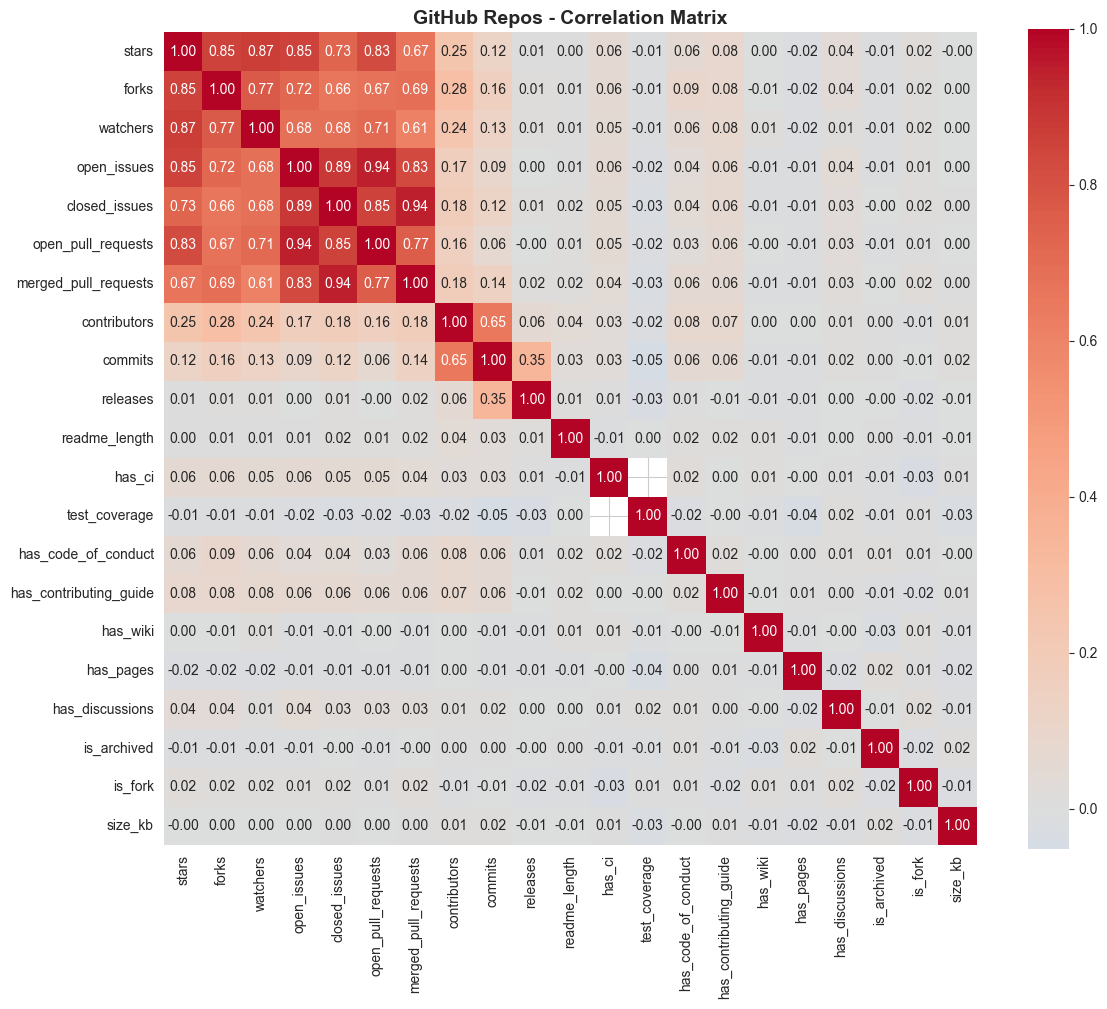


🔗 STRONGEST CORRELATIONS:
  closed_issues ↔ merged_pull_requests: 0.945
  open_issues ↔ open_pull_requests: 0.945
  open_issues ↔ closed_issues: 0.888
  stars ↔ watchers: 0.869
  stars ↔ open_issues: 0.853
  closed_issues ↔ open_pull_requests: 0.852
  stars ↔ forks: 0.850
  open_issues ↔ merged_pull_requests: 0.828

✅ DEEP ANALYSIS COMPLETED!


In [ ]:
# ============================================================================
# 5. CORRELATION AND NUMERIC ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("CORRELATION ANALYSIS")
print("="*80)

if 'github_repo_metrics' in loaded_data:
    gh_df = loaded_data['github_repo_metrics']
    numeric_cols_gh = gh_df.select_dtypes(include=[np.number]).columns
    
    # Correlation matrix
    if len(numeric_cols_gh) > 0:
        corr_matrix = gh_df[numeric_cols_gh].corr()
        
        # Plot correlation heatmap
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
        ax.set_title('GitHub Repos - Correlation Matrix', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # Strongest correlations
        print("\nSTRONGEST CORRELATIONS:")
        corr_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
        corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
        for col1, col2, corr in corr_pairs[:8]:
            print(f"  {col1} ↔ {col2}: {corr:.3f}")

print("\n✅ DEEP ANALYSIS COMPLETED!")